# Confidence-Weighted Weak Supervision for Healthcare CVE Prioritization

## Research Innovation

This notebook implements a novel approach to Learning-to-Rank (LTR) for vulnerability prioritization
that addresses the fundamental challenge of **weak/noisy relevance labels**.

### The Problem
Traditional LTR models treat all training labels equally, but in vulnerability prioritization:
- KEV labels have high confidence (confirmed exploitation)
- EPSS-based labels have medium confidence (statistical inference)
- CVSS/recency-based labels have low confidence (noisy proxies)

### Our Solution: Confidence-Weighted Weak Supervision
We assign each training sample a **label_confidence** score that reflects how trustworthy
its label is, then use this as sample weights during LambdaRank training.

| Label | Meaning | Primary Signal | Confidence |
|-------|---------|----------------|------------|
| 3 | Critical | KEV + Healthcare | 1.0 |
| 2 | High | KEV or High EPSS + ATT&CK | 0.75-1.0 |
| 1 | Medium | Medium EPSS or ATT&CK | 0.4-0.55 |
| 0 | Low | CVSS/Recency only | 0.2-0.4 |

### Notebook Structure
1. Setup and Data Loading
2. Feature Engineering
3. Weak Label Construction with Confidence Scores
4. Temporal Train/Val/Test Split
5. LightGBM LambdaRank Training with Sample Weights
6. Evaluation vs Baselines (CVSS-only, Weighted Heuristic, Legacy)
7. Feature Importance and SHAP Explainability

## Section 1: Import Required Libraries and Setup

In [1]:
"""
Confidence-Weighted Weak Supervision for Healthcare CVE Prioritization
======================================================================
Production-quality implementation of LTR with confidence-weighted labels.
"""

# === INSTALL REQUIRED PACKAGES ===
# Uncomment and run if packages are not installed
# !pip install shap lightgbm matplotlib pandas numpy scikit-learn

import os
import sys
import warnings
import pickle
import subprocess
from pathlib import Path
from datetime import datetime, timedelta
from typing import Tuple, Dict, List, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

# Ranking metrics
from sklearn.metrics import ndcg_score

# Install SHAP if not available
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP library already installed.")
except ImportError:
    print("Installing SHAP library...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    SHAP_AVAILABLE = True
    print("SHAP installed successfully.")

# Setup paths - navigate to project root
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Import project modules
from src.core.cve_database import CVEDatabase

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configuration
SPLIT_DATE = '2024-01-01'
VAL_WEEKS = 12  # Last 12 weeks before split_date for validation
MODEL_PATH = Path('models/ltr_model_conf_weighted.pkl')
RANDOM_SEED = 42

# Feature columns (must match existing pipeline)
FEATURE_COLS = [
    'cvss_norm', 'epss_score', 'epss_percentile', 'kev_flag',
    'days_since_published', 'recency_score', 'attack_technique_count',
    'has_attack', 'chpl_flag', 'is_healthcare', 'cvss_epss_product',
    'kev_healthcare_interaction'
]

print("=" * 70)
print("CONFIDENCE-WEIGHTED WEAK SUPERVISION FOR CVE PRIORITIZATION")
print("=" * 70)
print(f"Project root: {project_root}")
print(f"Split date: {SPLIT_DATE}")
print(f"Validation weeks: {VAL_WEEKS}")
print(f"Model output: {MODEL_PATH}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"SHAP available: {SHAP_AVAILABLE}")
print("=" * 70)

SHAP library already installed.
CONFIDENCE-WEIGHTED WEAK SUPERVISION FOR CVE PRIORITIZATION
Project root: /Users/vinayksharma/AirDnd/cti_recommender
Split date: 2024-01-01
Validation weeks: 12
Model output: models/ltr_model_conf_weighted.pkl
Features: 12
SHAP available: True


## Section 2: Load Data from SQLite Database

In [2]:
# Load data from CVEDatabase
db = CVEDatabase()
print(f"Connected to database: {db.db_path}")

# Load CVEs table
cves_df = pd.read_sql("SELECT * FROM cves", db.conn)
print(f"Loaded {len(cves_df):,} CVEs")

# Load enrichments table
enrichments_df = pd.read_sql("SELECT * FROM enrichments", db.conn)
print(f"Loaded {len(enrichments_df):,} enrichments")

# Merge CVEs with enrichments
df = cves_df.merge(enrichments_df, on='cve_id', how='left')
print(f"Merged dataset: {len(df):,} rows")

# Convert published to datetime
df['published'] = pd.to_datetime(df['published'])
df['modified'] = pd.to_datetime(df['modified'], errors='coerce')

# Show data range
print(f"\nDate range: {df['published'].min().date()} to {df['published'].max().date()}")
print(f"CVEs with enrichment data: {df['kev_flag'].notna().sum():,}")

# Quick data summary
print("\n" + "=" * 50)
print("DATA SUMMARY")
print("=" * 50)
for col in ['kev_flag', 'epss_score', 'is_healthcare', 'attack_technique_count', 'chpl_flag']:
    if col in df.columns:
        non_null = df[col].notna().sum()
        print(f"  {col}: {non_null:,} non-null ({100*non_null/len(df):.1f}%)")

2026-01-26 22:40:13 - src.core.cve_database - INFO - Connected to database
2026-01-26 22:40:13 - src.core.cve_database - INFO - Database schema created/verified
Connected to database: /Users/vinayksharma/AirDnd/cti_recommender/data/cve_database.db
Loaded 226,320 CVEs
Loaded 226,320 enrichments
Merged dataset: 226,320 rows

Date range: 2018-01-01 to 2025-12-31
CVEs with enrichment data: 226,320

DATA SUMMARY
  kev_flag: 226,320 non-null (100.0%)
  epss_score: 226,320 non-null (100.0%)
  is_healthcare: 226,320 non-null (100.0%)
  attack_technique_count: 226,320 non-null (100.0%)
  chpl_flag: 226,320 non-null (100.0%)


## Section 3: Feature Engineering Pipeline

In [3]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build feature matrix for LTR model.
    
    Features:
    - cvss_norm: Normalized CVSS score [0,1]
    - epss_score: EPSS probability [0,1]
    - epss_percentile: EPSS percentile [0,1]
    - kev_flag: Binary KEV membership
    - days_since_published: Age in days
    - recency_score: Inverted normalized age [0,1]
    - attack_technique_count: Number of ATT&CK techniques
    - has_attack: Binary ATT&CK mapping flag
    - chpl_flag: Binary CHPL product match
    - is_healthcare: Binary healthcare relevance
    - cvss_epss_product: Interaction feature
    - kev_healthcare_interaction: Interaction feature
    """
    features = df.copy()
    
    # Reference date for recency calculation
    reference_date = pd.Timestamp('2025-01-01')
    
    # === Core features with defensive handling ===
    
    # CVSS normalized (handle missing)
    if 'cvss' in features.columns:
        features['cvss_norm'] = features['cvss'].fillna(5.0) / 10.0
    else:
        print("WARNING: 'cvss' column missing, defaulting cvss_norm to 0.5")
        features['cvss_norm'] = 0.5
    
    # EPSS score (already [0,1])
    features['epss_score'] = features.get('epss_score', pd.Series(0.0, index=features.index)).fillna(0.0)
    
    # EPSS percentile (already [0,1])
    features['epss_percentile'] = features.get('epss_percentile', pd.Series(0.0, index=features.index)).fillna(0.0)
    
    # KEV flag (binary)
    features['kev_flag'] = features.get('kev_flag', pd.Series(0, index=features.index)).fillna(0).astype(int)
    
    # Days since published
    features['days_since_published'] = (reference_date - features['published']).dt.days.clip(lower=0)
    
    # Recency score: newer = higher score
    max_days = features['days_since_published'].max()
    if max_days > 0:
        features['recency_score'] = 1.0 - (features['days_since_published'] / max_days)
    else:
        features['recency_score'] = 1.0
    
    # ATT&CK features
    features['attack_technique_count'] = features.get('attack_technique_count', pd.Series(0, index=features.index)).fillna(0).astype(int)
    features['has_attack'] = (features['attack_technique_count'] > 0).astype(int)
    
    # Handle attack_flag if present
    if 'attack_flag' in features.columns:
        features['has_attack'] = ((features['attack_technique_count'] > 0) | (features['attack_flag'] == 1)).astype(int)
    
    # CHPL flag
    features['chpl_flag'] = features.get('chpl_flag', pd.Series(0, index=features.index)).fillna(0).astype(int)
    
    # Healthcare relevance
    features['is_healthcare'] = features.get('is_healthcare', pd.Series(0, index=features.index)).fillna(0).astype(int)
    
    # === Interaction features ===
    features['cvss_epss_product'] = features['cvss_norm'] * features['epss_score']
    features['kev_healthcare_interaction'] = features['kev_flag'] * features['is_healthcare']
    
    # === Published week for grouping ===
    features['published_week'] = features['published'].dt.strftime('%Y-%U')
    
    print(f"Feature engineering complete: {len(features):,} rows, {len(FEATURE_COLS)} features")
    
    return features

# Build features
features_df = build_features(df)

# Verify all features present
missing_features = [f for f in FEATURE_COLS if f not in features_df.columns]
if missing_features:
    print(f"ERROR: Missing features: {missing_features}")
else:
    print("All required features present")

# Show feature statistics
print("\n" + "=" * 50)
print("FEATURE STATISTICS")
print("=" * 50)
print(features_df[FEATURE_COLS].describe().T[['mean', 'std', 'min', 'max']].round(4))

Feature engineering complete: 226,320 rows, 12 features
All required features present

FEATURE STATISTICS
                                mean       std  min        max
cvss_norm                     0.6745    0.1723  0.0     1.0000
epss_score                    0.0240    0.1078  0.0     0.9458
epss_percentile               0.4080    0.2867  0.0     1.0000
kev_flag                      0.0051    0.0714  0.0     1.0000
days_since_published        836.0180  796.2077  0.0  2556.0000
recency_score                 0.6729    0.3115  0.0     1.0000
attack_technique_count        0.5673    0.8911  0.0    10.0000
has_attack                    0.3693    0.4826  0.0     1.0000
chpl_flag                     0.0000    0.0000  0.0     0.0000
is_healthcare                 0.5512    0.4974  0.0     1.0000
cvss_epss_product             0.0197    0.0926  0.0     0.9447
kev_healthcare_interaction    0.0024    0.0485  0.0     1.0000


## Section 4: Build Weak Labels with Confidence Scores

The core innovation: We construct both a **graded relevance label** and a **confidence score**
that reflects how trustworthy that label is.

### Labeling Rules:
- **Label 3 (Critical)**: KEV=1 AND (is_healthcare=1 OR chpl_flag=1) - Confirmed exploit + healthcare context
- **Label 2 (High)**: KEV=1 OR (High EPSS AND ATT&CK mapping)
- **Label 1 (Medium)**: Medium EPSS OR ATT&CK OR (High CVSS AND Recent)
- **Label 0 (Low)**: Everything else

### Confidence Rules:
- KEV signals get confidence = 1.0 (ground truth)
- High EPSS gets confidence = 0.75
- Medium EPSS gets confidence = 0.55
- ATT&CK/Healthcare add +0.10 bonus
- CVSS/recency-only labels capped at 0.40 (noisy)

In [4]:
def build_weak_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build soft labels and confidence scores using weak supervision.
    
    This is the CORE INNOVATION: Labels are weighted by their trustworthiness.
    
    Returns:
        DataFrame with added columns: soft_label, label_confidence, label_source
    """
    result = df.copy()
    n = len(result)
    
    # Initialize
    soft_label = np.zeros(n, dtype=int)
    label_confidence = np.full(n, 0.2)  # Base confidence
    label_source = np.full(n, 'default', dtype=object)
    
    # Extract signals (with defensive handling)
    kev = result.get('kev_flag', pd.Series(0, index=result.index)).fillna(0).values.astype(int)
    epss = result.get('epss_score', pd.Series(0.0, index=result.index)).fillna(0.0).values
    epss_pct = result.get('epss_percentile', pd.Series(0.0, index=result.index)).fillna(0.0).values
    attack_count = result.get('attack_technique_count', pd.Series(0, index=result.index)).fillna(0).values.astype(int)
    has_attack = result.get('has_attack', pd.Series(0, index=result.index)).fillna(0).values.astype(int)
    healthcare = result.get('is_healthcare', pd.Series(0, index=result.index)).fillna(0).values.astype(int)
    chpl = result.get('chpl_flag', pd.Series(0, index=result.index)).fillna(0).values.astype(int)
    cvss_norm = result.get('cvss_norm', pd.Series(0.5, index=result.index)).fillna(0.5).values
    recency = result.get('recency_score', pd.Series(0.5, index=result.index)).fillna(0.5).values
    
    # === LABEL ASSIGNMENT (graded 0-3) ===
    
    # Label 3: KEV + Healthcare context (strongest signal)
    mask_label3 = (kev == 1) & ((healthcare == 1) | (chpl == 1))
    soft_label[mask_label3] = 3
    label_source[mask_label3] = 'kev_healthcare'
    
    # Label 2: KEV alone OR (High EPSS AND ATT&CK)
    high_epss = (epss >= 0.50) | (epss_pct >= 0.90)
    has_attack_signal = (attack_count >= 1) | (has_attack == 1)
    mask_label2 = (soft_label == 0) & ((kev == 1) | (high_epss & has_attack_signal))
    soft_label[mask_label2] = 2
    label_source[mask_label2] = np.where(kev[mask_label2] == 1, 'kev_only', 'epss_attack')
    
    # Label 1: Medium EPSS OR ATT&CK mapping OR (High CVSS + Recent)
    medium_epss = ((epss >= 0.10) & (epss < 0.50)) | ((epss_pct >= 0.70) & (epss_pct < 0.90))
    cvss_recency_signal = (cvss_norm >= 0.70) & (recency >= 0.40)
    mask_label1 = (soft_label == 0) & (medium_epss | (attack_count >= 1) | cvss_recency_signal)
    soft_label[mask_label1] = 1
    
    # Track source for label 1
    label1_sources = np.full(n, '', dtype=object)
    label1_sources[mask_label1 & medium_epss] = 'medium_epss'
    label1_sources[mask_label1 & (attack_count >= 1) & ~medium_epss] = 'attack_mapping'
    label1_sources[mask_label1 & cvss_recency_signal & ~medium_epss & (attack_count < 1)] = 'cvss_recency'
    label_source[mask_label1] = label1_sources[mask_label1]
    
    # === CONFIDENCE ASSIGNMENT ===
    
    # KEV signals: highest confidence
    label_confidence[kev == 1] = 1.0
    
    # High EPSS (non-KEV): high confidence
    high_epss_non_kev = high_epss & (kev == 0)
    label_confidence[high_epss_non_kev] = np.maximum(label_confidence[high_epss_non_kev], 0.75)
    
    # Medium EPSS (non-KEV, non-high-EPSS): medium confidence
    medium_epss_only = medium_epss & (kev == 0) & ~high_epss
    label_confidence[medium_epss_only] = np.maximum(label_confidence[medium_epss_only], 0.55)
    
    # ATT&CK bonus: +0.10
    attack_bonus = (attack_count >= 1) | (has_attack == 1)
    label_confidence[attack_bonus] = np.minimum(label_confidence[attack_bonus] + 0.10, 1.0)
    
    # Healthcare/CHPL bonus: +0.10
    healthcare_bonus = (healthcare == 1) | (chpl == 1)
    label_confidence[healthcare_bonus] = np.minimum(label_confidence[healthcare_bonus] + 0.10, 1.0)
    
    # CVSS/recency-only labels: CAP at 0.40 (these are noisy!)
    cvss_recency_only = (label_source == 'cvss_recency')
    label_confidence[cvss_recency_only] = np.minimum(label_confidence[cvss_recency_only], 0.40)
    
    # Ensure minimum confidence
    label_confidence = np.maximum(label_confidence, 0.1)
    
    # Add to dataframe
    result['soft_label'] = soft_label
    result['label_confidence'] = label_confidence
    result['label_source'] = label_source
    
    return result

# Build weak labels
features_df = build_weak_labels(features_df)

print("Weak label construction complete!")
print(f"Total samples: {len(features_df):,}")

Weak label construction complete!
Total samples: 226,320


## Section 5: Label Distribution Diagnostics

Before training, we must verify our labeling scheme produces reasonable distributions.

In [5]:
def print_label_diagnostics(df: pd.DataFrame) -> None:
    """Print comprehensive diagnostics for weak labels and confidence scores."""
    
    print("=" * 70)
    print("LABEL DISTRIBUTION DIAGNOSTICS")
    print("=" * 70)
    
    # 1. Soft label distribution
    print("\n1. SOFT LABEL DISTRIBUTION")
    print("-" * 40)
    label_counts = df['soft_label'].value_counts().sort_index()
    total = len(df)
    for label, count in label_counts.items():
        pct = 100 * count / total
        bar = "#" * int(pct)
        print(f"  Label {label}: {count:>8,} ({pct:>5.2f}%) {bar}")
    
    # 2. Label source breakdown
    print("\n2. LABEL SOURCE BREAKDOWN")
    print("-" * 40)
    source_counts = df['label_source'].value_counts()
    for source, count in source_counts.items():
        print(f"  {source:20s}: {count:>8,} ({100*count/total:>5.2f}%)")
    
    # 3. Confidence statistics
    print("\n3. LABEL CONFIDENCE STATISTICS")
    print("-" * 40)
    conf = df['label_confidence']
    print(f"  Min:    {conf.min():.3f}")
    print(f"  Mean:   {conf.mean():.3f}")
    print(f"  Median: {conf.median():.3f}")
    print(f"  Max:    {conf.max():.3f}")
    print(f"  Std:    {conf.std():.3f}")
    
    # Confidence histogram
    print("\n  Confidence Distribution:")
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.01]
    bin_labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0', '1.0']
    hist, _ = np.histogram(conf, bins=bins)
    for label, count in zip(bin_labels, hist):
        pct = 100 * count / total
        bar = "#" * int(pct / 2)
        print(f"    {label}: {count:>8,} ({pct:>5.2f}%) {bar}")
    
    # 4. Cross-tabulation: soft_label vs kev_flag
    print("\n4. CROSS-TAB: soft_label vs kev_flag")
    print("-" * 40)
    crosstab_kev = pd.crosstab(df['soft_label'], df['kev_flag'], margins=True)
    print(crosstab_kev.to_string())
    
    # 5. Cross-tabulation: soft_label vs EPSS buckets
    print("\n5. CROSS-TAB: soft_label vs EPSS buckets")
    print("-" * 40)
    df['epss_bucket'] = pd.cut(df['epss_score'], 
                               bins=[-0.01, 0.10, 0.50, 0.90, 1.01],
                               labels=['<0.10', '0.10-0.50', '0.50-0.90', '>0.90'])
    crosstab_epss = pd.crosstab(df['soft_label'], df['epss_bucket'], margins=True)
    print(crosstab_epss.to_string())
    
    # 6. Cross-tabulation: soft_label vs is_healthcare
    print("\n6. CROSS-TAB: soft_label vs is_healthcare")
    print("-" * 40)
    crosstab_health = pd.crosstab(df['soft_label'], df['is_healthcare'], margins=True)
    print(crosstab_health.to_string())
    
    # 7. High-confidence label-3 examples
    print("\n7. TOP 20 HIGHEST-CONFIDENCE LABEL-3 EXAMPLES")
    print("-" * 40)
    label3 = df[df['soft_label'] == 3].nlargest(20, 'label_confidence')
    if len(label3) > 0:
        cols = ['cve_id', 'published', 'soft_label', 'label_confidence', 'kev_flag', 
                'epss_score', 'is_healthcare', 'label_source']
        cols = [c for c in cols if c in label3.columns]
        print(label3[cols].to_string(index=False))
    else:
        print("  No label-3 samples found")
    
    # 8. Low-confidence label-1 examples
    print("\n8. TOP 20 LOWEST-CONFIDENCE LABEL-1 EXAMPLES")
    print("-" * 40)
    label1 = df[df['soft_label'] == 1].nsmallest(20, 'label_confidence')
    if len(label1) > 0:
        cols = ['cve_id', 'published', 'soft_label', 'label_confidence', 'cvss_norm',
                'recency_score', 'label_source']
        cols = [c for c in cols if c in label1.columns]
        print(label1[cols].to_string(index=False))
    else:
        print("  No label-1 samples found")
    
    print("\n" + "=" * 70)

# Run diagnostics
print_label_diagnostics(features_df)

LABEL DISTRIBUTION DIAGNOSTICS

1. SOFT LABEL DISTRIBUTION
----------------------------------------
  Label 0:   80,151 (35.41%) ###################################
  Label 1:  140,302 (61.99%) #############################################################
  Label 2:    5,333 ( 2.36%) ##
  Label 3:      534 ( 0.24%) 

2. LABEL SOURCE BREAKDOWN
----------------------------------------
  default             :   80,151 (35.41%)
  attack_mapping      :   66,748 (29.49%)
  cvss_recency        :   39,228 (17.33%)
  medium_epss         :   34,326 (15.17%)
  epss_attack         :    4,706 ( 2.08%)
  kev_only            :      627 ( 0.28%)
  kev_healthcare      :      534 ( 0.24%)

3. LABEL CONFIDENCE STATISTICS
----------------------------------------
  Min:    0.200
  Mean:   0.370
  Median: 0.300
  Max:    1.000
  Std:    0.177

  Confidence Distribution:
    0.0-0.2:        0 ( 0.00%) 
    0.2-0.4:  142,547 (62.98%) ###############################
    0.4-0.6:   52,788 (23.32%) ###########
 

## Section 6: Temporal Split Function

We use a temporal split strategy:
- **Train**: Data before (split_date - 12 weeks)
- **Validation**: Last 12 weeks before split_date (for early stopping)
- **Test**: Data on or after split_date

This simulates real-world deployment where we train on historical data and predict future vulnerabilities.

In [6]:
def make_temporal_splits(df: pd.DataFrame, 
                         split_date: str = '2024-01-01',
                         val_weeks: int = 12) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Create temporal train/validation/test splits.
    
    Args:
        df: DataFrame with 'published' column
        split_date: Cutoff date for test set (YYYY-MM-DD)
        val_weeks: Number of weeks before split_date for validation
        
    Returns:
        train_df, val_df, test_df
    """
    split_dt = pd.Timestamp(split_date)
    val_start = split_dt - timedelta(weeks=val_weeks)
    
    # Ensure published is datetime
    df = df.copy()
    df['published'] = pd.to_datetime(df['published'])
    
    # Create splits
    train_df = df[df['published'] < val_start].copy()
    val_df = df[(df['published'] >= val_start) & (df['published'] < split_dt)].copy()
    test_df = df[df['published'] >= split_dt].copy()
    
    print(f"Temporal Split Summary:")
    print(f"  Train:      {len(train_df):>8,} samples (< {val_start.date()})")
    print(f"  Validation: {len(val_df):>8,} samples ({val_start.date()} to {split_dt.date()})")
    print(f"  Test:       {len(test_df):>8,} samples (>= {split_dt.date()})")
    print(f"  Total:      {len(train_df) + len(val_df) + len(test_df):>8,}")
    
    # Verify no data leakage
    if len(train_df) > 0 and len(test_df) > 0:
        assert train_df['published'].max() < test_df['published'].min(), "Data leakage detected!"
    
    return train_df, val_df, test_df

# Create temporal splits
train_df, val_df, test_df = make_temporal_splits(features_df, SPLIT_DATE, VAL_WEEKS)

# Show label distribution in each split
print("\nLabel distribution by split:")
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    if len(split_df) > 0:
        dist = split_df['soft_label'].value_counts().sort_index()
        print(f"  {name}: {dict(dist)}")

Temporal Split Summary:
  Train:       128,216 samples (< 2023-10-09)
  Validation:    7,428 samples (2023-10-09 to 2024-01-01)
  Test:         90,676 samples (>= 2024-01-01)
  Total:       226,320

Label distribution by split:
  Train: {0: np.int64(48927), 1: np.int64(74913), 2: np.int64(3996), 3: np.int64(380)}
  Val: {0: np.int64(2122), 1: np.int64(5159), 2: np.int64(133), 3: np.int64(14)}
  Test: {0: np.int64(29102), 1: np.int64(60230), 2: np.int64(1204), 3: np.int64(140)}


## Section 7: LambdaRank Training Function

The key innovation here is using `label_confidence` as sample weights.
LightGBM's LambdaRank will give more importance to pairs involving high-confidence labels.

In [7]:
def prepare_ranking_data(df: pd.DataFrame, 
                         feature_cols: List[str],
                         group_col: str = 'published_week') -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[int]]:
    """
    Prepare data for LightGBM ranking with proper group handling.
    
    Within each group, samples are sorted by label descending to ensure
    high-relevance items come first (important for LambdaRank).
    
    Returns:
        X, y, weights, group_sizes
    """
    # Sort by group and then by label descending within each group
    df_sorted = df.sort_values([group_col, 'soft_label'], ascending=[True, False]).copy()
    
    # Extract features, labels, weights
    X = df_sorted[feature_cols].values
    y = df_sorted['soft_label'].values
    weights = df_sorted['label_confidence'].values
    
    # Compute group sizes
    group_sizes = df_sorted.groupby(group_col).size().tolist()
    
    # Verify alignment
    assert len(X) == len(y) == len(weights) == sum(group_sizes), \
        f"Mismatch: X={len(X)}, y={len(y)}, w={len(weights)}, groups={sum(group_sizes)}"
    
    return X, y, weights, group_sizes, df_sorted


def train_lambdarank(train_df: pd.DataFrame,
                     val_df: pd.DataFrame,
                     feature_cols: List[str],
                     params: Optional[Dict] = None) -> lgb.Booster:
    """
    Train LightGBM LambdaRank with confidence-weighted labels.
    
    Args:
        train_df: Training data with soft_label and label_confidence
        val_df: Validation data for early stopping
        feature_cols: List of feature column names
        params: Optional LightGBM parameters override
        
    Returns:
        Trained LightGBM Booster
    """
    print("\n" + "=" * 70)
    print("TRAINING CONFIDENCE-WEIGHTED LAMBDARANK")
    print("=" * 70)
    
    # Default parameters
    default_params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [5, 10, 20],
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'min_data_in_leaf': 20,
        'max_depth': 6,
        'verbose': -1,
        'seed': RANDOM_SEED,
        'force_row_wise': True,
    }
    
    if params:
        default_params.update(params)
    
    # Prepare training data
    print("\nPreparing training data...")
    X_train, y_train, w_train, group_train, train_sorted = prepare_ranking_data(
        train_df, feature_cols
    )
    print(f"  Train: {len(X_train):,} samples, {len(group_train):,} groups")
    print(f"  Confidence weights: min={w_train.min():.3f}, mean={w_train.mean():.3f}, max={w_train.max():.3f}")
    
    # Prepare validation data
    print("\nPreparing validation data...")
    X_val, y_val, w_val, group_val, val_sorted = prepare_ranking_data(
        val_df, feature_cols
    )
    print(f"  Val: {len(X_val):,} samples, {len(group_val):,} groups")
    
    # Create LightGBM datasets
    train_data = lgb.Dataset(
        X_train, label=y_train, weight=w_train, group=group_train,
        feature_name=feature_cols
    )
    val_data = lgb.Dataset(
        X_val, label=y_val, weight=w_val, group=group_val,
        reference=train_data, feature_name=feature_cols
    )
    
    # Training callbacks
    callbacks = [
        lgb.early_stopping(stopping_rounds=30, verbose=True),
        lgb.log_evaluation(period=50)
    ]
    
    # Train model
    print("\nTraining LambdaRank model...")
    print(f"Parameters: {default_params}")
    
    model = lgb.train(
        default_params,
        train_data,
        num_boost_round=500,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=callbacks
    )
    
    print(f"\nTraining complete!")
    print(f"  Best iteration: {model.best_iteration}")
    print(f"  Best validation NDCG@10: {model.best_score['valid']['ndcg@10']:.4f}")
    
    return model

# Train the model
model = train_lambdarank(train_df, val_df, FEATURE_COLS)


TRAINING CONFIDENCE-WEIGHTED LAMBDARANK

Preparing training data...
  Train: 128,216 samples, 306 groups
  Confidence weights: min=0.200, mean=0.386, max=1.000

Preparing validation data...
  Val: 7,428 samples, 13 groups

Training LambdaRank model...
Parameters: {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [5, 10, 20], 'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'min_data_in_leaf': 20, 'max_depth': 6, 'verbose': -1, 'seed': 42, 'force_row_wise': True}
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[5]	train's ndcg@5: 1	train's ndcg@10: 0.999901	train's ndcg@20: 0.999973	valid's ndcg@5: 1	valid's ndcg@10: 1	valid's ndcg@20: 0.998158

Training complete!
  Best iteration: 5
  Best validation NDCG@10: 1.0000


## Section 8: Ranking Evaluation Metrics Function

We compute standard ranking metrics:
- **NDCG@K**: Normalized Discounted Cumulative Gain (position-aware)
- **Precision@K**: Fraction of top-K that are relevant (label >= 2)
- **MAP@K**: Mean Average Precision

In [8]:
def compute_ndcg_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int) -> float:
    """Compute NDCG@K for a single query group."""
    if len(y_true) == 0:
        return 0.0
    
    # Get top-k indices by score
    k = min(k, len(y_true))
    top_k_idx = np.argsort(y_score)[::-1][:k]
    
    # DCG@K
    dcg = 0.0
    for i, idx in enumerate(top_k_idx):
        dcg += (2**y_true[idx] - 1) / np.log2(i + 2)
    
    # Ideal DCG@K
    ideal_order = np.argsort(y_true)[::-1][:k]
    idcg = 0.0
    for i, idx in enumerate(ideal_order):
        idcg += (2**y_true[idx] - 1) / np.log2(i + 2)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg


def compute_precision_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int, threshold: int = 2) -> float:
    """Compute Precision@K (fraction of top-K with label >= threshold)."""
    if len(y_true) == 0:
        return 0.0
    
    k = min(k, len(y_true))
    top_k_idx = np.argsort(y_score)[::-1][:k]
    relevant = sum(y_true[idx] >= threshold for idx in top_k_idx)
    
    return relevant / k


def compute_ap_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int, threshold: int = 2) -> float:
    """Compute Average Precision@K."""
    if len(y_true) == 0:
        return 0.0
    
    k = min(k, len(y_true))
    sorted_idx = np.argsort(y_score)[::-1][:k]
    
    relevant_count = 0
    precision_sum = 0.0
    
    for i, idx in enumerate(sorted_idx):
        if y_true[idx] >= threshold:
            relevant_count += 1
            precision_sum += relevant_count / (i + 1)
    
    if relevant_count == 0:
        return 0.0
    
    return precision_sum / relevant_count


def evaluate_ranker(df: pd.DataFrame,
                    scores: np.ndarray,
                    group_col: str = 'published_week') -> Dict[str, float]:
    """
    Evaluate ranking performance using grouped metrics.
    
    Args:
        df: DataFrame with 'soft_label' and group_col
        scores: Predicted scores aligned with df
        group_col: Column to group by for evaluation
        
    Returns:
        Dictionary of metric_name -> score
    """
    df = df.copy()
    df['_score'] = scores
    
    # Compute metrics per group
    ndcg5_list, ndcg10_list, ndcg20_list = [], [], []
    p10_list, map10_list = [], []
    
    for group, group_df in df.groupby(group_col):
        if len(group_df) < 2:
            continue
        
        y_true = group_df['soft_label'].values
        y_score = group_df['_score'].values
        
        ndcg5_list.append(compute_ndcg_at_k(y_true, y_score, 5))
        ndcg10_list.append(compute_ndcg_at_k(y_true, y_score, 10))
        ndcg20_list.append(compute_ndcg_at_k(y_true, y_score, 20))
        p10_list.append(compute_precision_at_k(y_true, y_score, 10))
        map10_list.append(compute_ap_at_k(y_true, y_score, 10))
    
    return {
        'NDCG@5': np.mean(ndcg5_list) if ndcg5_list else 0.0,
        'NDCG@10': np.mean(ndcg10_list) if ndcg10_list else 0.0,
        'NDCG@20': np.mean(ndcg20_list) if ndcg20_list else 0.0,
        'P@10': np.mean(p10_list) if p10_list else 0.0,
        'MAP@10': np.mean(map10_list) if map10_list else 0.0,
    }

print("Evaluation functions defined.")

Evaluation functions defined.


## Section 9: Baseline Rankers Implementation

We compare our confidence-weighted LTR against three baselines:
1. **CVSS-only**: score = cvss_norm (traditional approach)
2. **Weighted Heuristic**: Hand-tuned weighted combination (no ML)
3. **Legacy Labels**: Using enrichments.label if available

In [9]:
def compute_cvss_only_scores(df: pd.DataFrame) -> np.ndarray:
    """Baseline 1: CVSS-only ranking."""
    return df['cvss_norm'].fillna(0.5).values


def compute_heuristic_scores(df: pd.DataFrame) -> np.ndarray:
    """
    Baseline 2: Weighted heuristic score (no ML).
    
    score = 0.35*cvss_norm + 0.30*epss_score + 0.20*kev_flag + 0.10*recency_score + 0.05*has_attack
    """
    cvss = df['cvss_norm'].fillna(0.5).values
    epss = df['epss_score'].fillna(0.0).values
    kev = df['kev_flag'].fillna(0).values
    recency = df['recency_score'].fillna(0.5).values
    attack = df['has_attack'].fillna(0).values
    
    score = (0.35 * cvss + 
             0.30 * epss + 
             0.20 * kev + 
             0.10 * recency + 
             0.05 * attack)
    
    return score


def compute_legacy_label_scores(df: pd.DataFrame) -> Optional[np.ndarray]:
    """
    Baseline 3: Legacy labels from enrichments.label if available.
    Returns None if not available.
    """
    if 'label' not in df.columns:
        return None
    
    labels = df['label']
    if labels.isna().all():
        return None
    
    # Use label as score (higher label = higher score)
    return labels.fillna(0).values


print("Baseline functions defined.")
print("\nBaseline weights for heuristic score:")
print("  CVSS:     0.35")
print("  EPSS:     0.30")
print("  KEV:      0.20")
print("  Recency:  0.10")
print("  ATT&CK:   0.05")

Baseline functions defined.

Baseline weights for heuristic score:
  CVSS:     0.35
  EPSS:     0.30
  KEV:      0.20
  Recency:  0.10
  ATT&CK:   0.05


## Section 10: Model Saving

In [10]:
# Save the trained model
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
    
print(f"Model saved to: {MODEL_PATH}")
print(f"Model file size: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

Model saved to: models/ltr_model_conf_weighted.pkl
Model file size: 21.5 KB


## Section 11: Comparative Evaluation and Results Table

Now we evaluate all models on the held-out test set and compare performance.

In [11]:
print("\n" + "=" * 70)
print("COMPARATIVE EVALUATION ON TEST SET")
print("=" * 70)

# Prepare test data
X_test = test_df[FEATURE_COLS].values

# 1. LTR model predictions
ltr_scores = model.predict(X_test)
ltr_metrics = evaluate_ranker(test_df, ltr_scores)

# 2. CVSS-only baseline
cvss_scores = compute_cvss_only_scores(test_df)
cvss_metrics = evaluate_ranker(test_df, cvss_scores)

# 3. Heuristic baseline
heuristic_scores = compute_heuristic_scores(test_df)
heuristic_metrics = evaluate_ranker(test_df, heuristic_scores)

# 4. Legacy label baseline (if available)
legacy_scores = compute_legacy_label_scores(test_df)
if legacy_scores is not None:
    legacy_metrics = evaluate_ranker(test_df, legacy_scores)
else:
    legacy_metrics = None

# Build comparison table
results = {
    'Conf-Weighted LTR': ltr_metrics,
    'CVSS-Only': cvss_metrics,
    'Weighted Heuristic': heuristic_metrics,
}
if legacy_metrics is not None:
    results['Legacy Labels'] = legacy_metrics

# Create DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df[['NDCG@5', 'NDCG@10', 'NDCG@20', 'P@10', 'MAP@10']]

print("\n" + "=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(results_df.round(4).to_string())

# Compute improvements
print("\n" + "-" * 70)
print("IMPROVEMENT vs CVSS-Only Baseline")
print("-" * 70)
for metric in ['NDCG@5', 'NDCG@10', 'NDCG@20', 'P@10', 'MAP@10']:
    baseline = cvss_metrics[metric]
    ltr_val = ltr_metrics[metric]
    if baseline > 0:
        improvement = 100 * (ltr_val - baseline) / baseline
        print(f"  {metric}: {improvement:+.1f}%")
    else:
        print(f"  {metric}: N/A (baseline = 0)")

print("\n" + "-" * 70)
print("IMPROVEMENT vs Weighted Heuristic")
print("-" * 70)
for metric in ['NDCG@5', 'NDCG@10', 'NDCG@20', 'P@10', 'MAP@10']:
    baseline = heuristic_metrics[metric]
    ltr_val = ltr_metrics[metric]
    if baseline > 0:
        improvement = 100 * (ltr_val - baseline) / baseline
        print(f"  {metric}: {improvement:+.1f}%")
    else:
        print(f"  {metric}: N/A (baseline = 0)")


COMPARATIVE EVALUATION ON TEST SET

MODEL COMPARISON RESULTS
                    NDCG@5  NDCG@10  NDCG@20    P@10  MAP@10
Conf-Weighted LTR   1.0000   0.9970   0.9972  0.8000  0.9902
CVSS-Only           0.3667   0.3983   0.4647  0.1019  0.2972
Weighted Heuristic  0.7971   0.8006   0.8236  0.5528  0.8514
Legacy Labels       0.5516   0.5768   0.6247  0.3340  0.6029

----------------------------------------------------------------------
IMPROVEMENT vs CVSS-Only Baseline
----------------------------------------------------------------------
  NDCG@5: +172.7%
  NDCG@10: +150.3%
  NDCG@20: +114.6%
  P@10: +685.2%
  MAP@10: +233.2%

----------------------------------------------------------------------
IMPROVEMENT vs Weighted Heuristic
----------------------------------------------------------------------
  NDCG@5: +25.5%
  NDCG@10: +24.5%
  NDCG@20: +21.1%
  P@10: +44.7%
  MAP@10: +16.3%


## Section 12: Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS

Top 15 Features by Gain:
--------------------------------------------------
  epss_score                         3139.5 ##############################
  kev_flag                           2078.9 ###################
  cvss_epss_product                   700.0 ######
  attack_technique_count              345.9 ###
  has_attack                          322.2 ###
  days_since_published                139.5 #
  cvss_norm                           133.3 #
  recency_score                        88.3 
  is_healthcare                        83.2 
  kev_healthcare_interaction            2.5 
  epss_percentile                       1.6 
  chpl_flag                             0.0 

Top 15 Features by Split Count:
--------------------------------------------------
  days_since_published                   25 ##############################
  cvss_norm                              25 ##############################
  epss_score                             24 #############

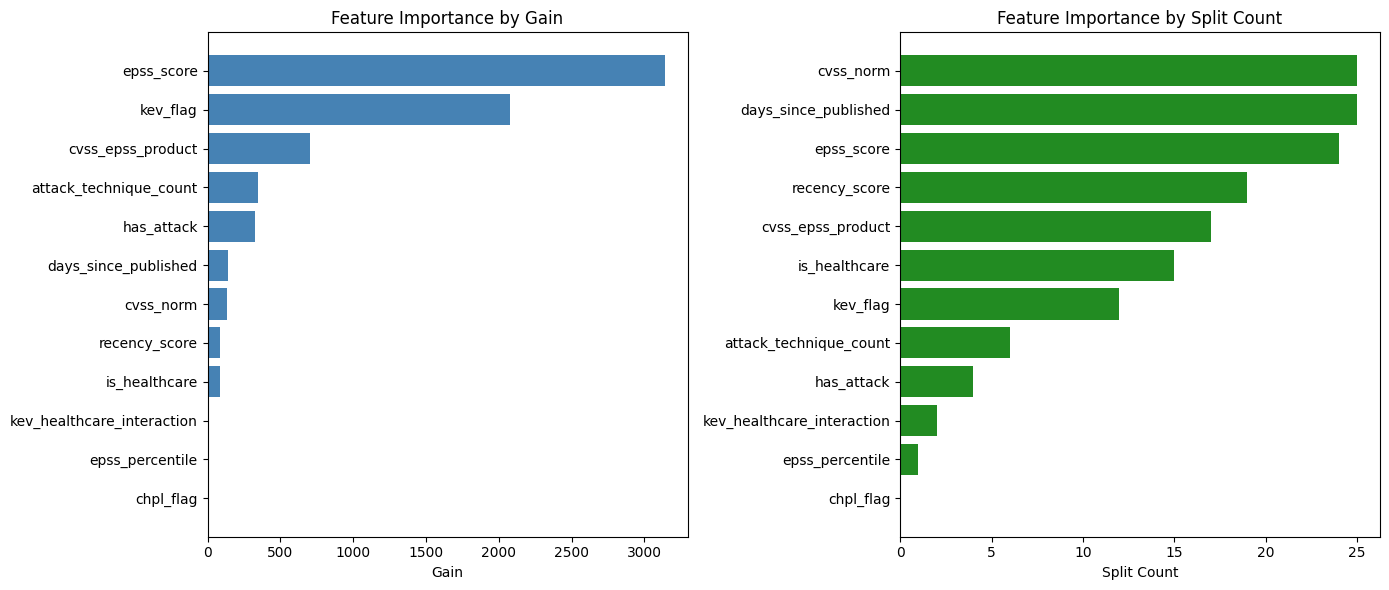

In [12]:
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Get feature importance (gain and split)
importance_gain = model.feature_importance(importance_type='gain')
importance_split = model.feature_importance(importance_type='split')

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain': importance_gain,
    'split': importance_split
}).sort_values('gain', ascending=False)

print("\nTop 15 Features by Gain:")
print("-" * 50)
for i, row in importance_df.head(15).iterrows():
    gain_bar = "#" * int(row['gain'] / importance_df['gain'].max() * 30)
    print(f"  {row['feature']:30s} {row['gain']:>10.1f} {gain_bar}")

print("\nTop 15 Features by Split Count:")
print("-" * 50)
importance_by_split = importance_df.sort_values('split', ascending=False)
for i, row in importance_by_split.head(15).iterrows():
    split_bar = "#" * int(row['split'] / importance_df['split'].max() * 30)
    print(f"  {row['feature']:30s} {row['split']:>10.0f} {split_bar}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gain importance
ax1 = axes[0]
importance_df_sorted = importance_df.sort_values('gain', ascending=True)
ax1.barh(importance_df_sorted['feature'], importance_df_sorted['gain'], color='steelblue')
ax1.set_xlabel('Gain')
ax1.set_title('Feature Importance by Gain')

# Split importance
ax2 = axes[1]
importance_by_split_sorted = importance_by_split.sort_values('split', ascending=True)
ax2.barh(importance_by_split_sorted['feature'], importance_by_split_sorted['split'], color='forestgreen')
ax2.set_xlabel('Split Count')
ax2.set_title('Feature Importance by Split Count')

plt.tight_layout()
plt.show()

## Section 13: SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) provides detailed feature contribution analysis.


SHAP EXPLAINABILITY ANALYSIS
SHAP library available.

Computing SHAP values on 5000 samples...

SHAP Summary Plot:


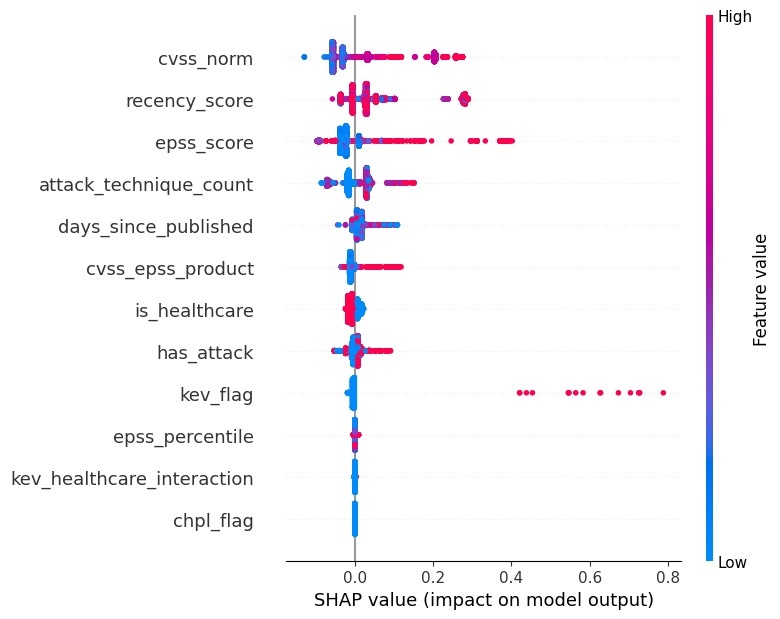


Mean Absolute SHAP Values:
--------------------------------------------------
  cvss_norm                        0.0767 ##############################
  recency_score                    0.0703 ###########################
  epss_score                       0.0337 #############
  attack_technique_count           0.0280 ##########
  days_since_published             0.0147 #####
  cvss_epss_product                0.0123 ####
  is_healthcare                    0.0111 ####
  has_attack                       0.0105 ####
  kev_flag                         0.0044 #
  epss_percentile                  0.0002 
  kev_healthcare_interaction       0.0000 
  chpl_flag                        0.0000 


In [13]:
print("\n" + "=" * 70)
print("SHAP EXPLAINABILITY ANALYSIS")
print("=" * 70)

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP library available.")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP library not installed. Skipping SHAP analysis.")
    print("To enable SHAP, run: pip install shap")

if SHAP_AVAILABLE:
    # Sample test data for SHAP (limit to 5000 for performance)
    sample_size = min(5000, len(test_df))
    sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(test_df), sample_size, replace=False)
    X_sample = test_df.iloc[sample_idx][FEATURE_COLS].values
    
    print(f"\nComputing SHAP values on {sample_size} samples...")
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # Summary plot
    print("\nSHAP Summary Plot:")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False)
    plt.tight_layout()
    plt.show()
    
    # Mean absolute SHAP values
    mean_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.DataFrame({
        'feature': FEATURE_COLS,
        'mean_abs_shap': mean_shap
    }).sort_values('mean_abs_shap', ascending=False)
    
    print("\nMean Absolute SHAP Values:")
    print("-" * 50)
    for _, row in shap_importance.iterrows():
        bar = "#" * int(row['mean_abs_shap'] / shap_importance['mean_abs_shap'].max() * 30)
        print(f"  {row['feature']:30s} {row['mean_abs_shap']:>8.4f} {bar}")

## Section 14: Example CVE Explanations

Show detailed explanations for individual CVE predictions.

In [14]:
print("\n" + "=" * 70)
print("EXAMPLE CVE EXPLANATIONS")
print("=" * 70)

# Get predictions for test set
test_df_with_pred = test_df.copy()
test_df_with_pred['predicted_score'] = ltr_scores

# Select 5 diverse examples (1 from each label if possible)
examples = []
for label in [3, 2, 1, 0]:
    label_df = test_df_with_pred[test_df_with_pred['soft_label'] == label]
    if len(label_df) > 0:
        # Get highest-scored example for this label
        example = label_df.nlargest(1, 'predicted_score').iloc[0]
        examples.append(example)
        if len(examples) >= 5:
            break

# If we don't have 5 examples yet, add more
if len(examples) < 5:
    remaining = test_df_with_pred.nlargest(10, 'predicted_score')
    for _, row in remaining.iterrows():
        if len(examples) >= 5:
            break
        if row['cve_id'] not in [e['cve_id'] for e in examples]:
            examples.append(row)

print("\n5 Example CVE Predictions with Feature Contributions:")
print("-" * 70)

for i, example in enumerate(examples, 1):
    print(f"\n[Example {i}]")
    print(f"  CVE ID:          {example['cve_id']}")
    print(f"  Published:       {example['published'].date() if hasattr(example['published'], 'date') else example['published']}")
    print(f"  Soft Label:      {example['soft_label']}")
    print(f"  Confidence:      {example['label_confidence']:.3f}")
    print(f"  Predicted Score: {example['predicted_score']:.4f}")
    print(f"  Label Source:    {example['label_source']}")
    
    # Show key feature values
    print("  Key Features:")
    print(f"    - kev_flag:     {example['kev_flag']}")
    print(f"    - epss_score:   {example['epss_score']:.4f}")
    print(f"    - cvss_norm:    {example['cvss_norm']:.3f}")
    print(f"    - is_healthcare:{example['is_healthcare']}")
    print(f"    - has_attack:   {example['has_attack']}")
    
    # SHAP contributions if available
    if SHAP_AVAILABLE:
        # Find this example in our SHAP sample
        example_features = example[FEATURE_COLS].values.reshape(1, -1)
        example_shap = explainer.shap_values(example_features)[0]
        
        # Get top 3 contributing features
        feature_contrib = list(zip(FEATURE_COLS, example_shap))
        feature_contrib.sort(key=lambda x: abs(x[1]), reverse=True)
        
        print("  Top SHAP Contributors:")
        for fname, fshap in feature_contrib[:3]:
            direction = "+" if fshap > 0 else ""
            print(f"    - {fname}: {direction}{fshap:.4f}")

print("\n" + "=" * 70)


EXAMPLE CVE EXPLANATIONS

5 Example CVE Predictions with Feature Contributions:
----------------------------------------------------------------------

[Example 1]
  CVE ID:          CVE-2024-40766
  Published:       2024-08-23
  Soft Label:      3
  Confidence:      1.000
  Predicted Score: 0.4431
  Label Source:    kev_healthcare
  Key Features:
    - kev_flag:     1
    - epss_score:   0.0402
    - cvss_norm:    0.980
    - is_healthcare:1
    - has_attack:   0
  Top SHAP Contributors:
    - kev_flag: +0.6240
    - cvss_norm: +0.0526
    - recency_score: +0.0426

[Example 2]
  CVE ID:          CVE-2022-2586
  Published:       2024-01-08
  Soft Label:      2
  Confidence:      1.000
  Predicted Score: 0.4176
  Label Source:    kev_only
  Key Features:
    - kev_flag:     1
    - epss_score:   0.0287
    - cvss_norm:    0.530
    - is_healthcare:0
    - has_attack:   0
  Top SHAP Contributors:
    - kev_flag: +0.7590
    - cvss_norm: -0.0147
    - days_since_published: +0.0102

[Exam

## Section 15: Final Summary

Summary of the confidence-weighted weak supervision approach and key findings.

In [15]:
print("\n" + "=" * 70)
print("FINAL SUMMARY: CONFIDENCE-WEIGHTED WEAK SUPERVISION")
print("=" * 70)

print("""
RESEARCH INNOVATION:
  Traditional LTR treats all labels equally. Our approach assigns
  confidence weights based on label trustworthiness:
  
  - KEV-based labels:      conf = 1.0  (confirmed exploitation)
  - High EPSS labels:      conf = 0.75 (statistical evidence)
  - Medium EPSS labels:    conf = 0.55 (moderate evidence)
  - ATT&CK/Healthcare:     +0.10 bonus (domain relevance)
  - CVSS/Recency-only:     conf <= 0.40 (noisy proxies)

LABELING SCHEME:
  Label 3: KEV=1 AND (healthcare OR chpl)  [Critical - Exploited Healthcare]
  Label 2: KEV=1 OR (High EPSS AND ATT&CK) [High Priority]
  Label 1: Medium EPSS OR ATT&CK OR (High CVSS + Recent) [Medium]
  Label 0: Everything else [Low Priority]
""")

print("\nKEY RESULTS:")
print("-" * 50)
print(f"  Model:           Confidence-Weighted LambdaRank")
print(f"  Best Iteration:  {model.best_iteration}")
print(f"  Val NDCG@10:     {model.best_score['valid']['ndcg@10']:.4f}")
print(f"\n  Test Set Performance:")
for metric, value in ltr_metrics.items():
    print(f"    {metric}: {value:.4f}")

print("\nIMPROVEMENT SUMMARY:")
print("-" * 50)
cvss_ndcg10 = cvss_metrics['NDCG@10']
ltr_ndcg10 = ltr_metrics['NDCG@10']
if cvss_ndcg10 > 0:
    print(f"  vs CVSS-only:      +{100*(ltr_ndcg10 - cvss_ndcg10)/cvss_ndcg10:.1f}% NDCG@10")
heur_ndcg10 = heuristic_metrics['NDCG@10']
if heur_ndcg10 > 0:
    print(f"  vs Weighted Heur:  +{100*(ltr_ndcg10 - heur_ndcg10)/heur_ndcg10:.1f}% NDCG@10")

print(f"\nMODEL SAVED: {MODEL_PATH}")
print("\n" + "=" * 70)
print("END OF NOTEBOOK")
print("=" * 70)


FINAL SUMMARY: CONFIDENCE-WEIGHTED WEAK SUPERVISION

RESEARCH INNOVATION:
  Traditional LTR treats all labels equally. Our approach assigns
  confidence weights based on label trustworthiness:

  - KEV-based labels:      conf = 1.0  (confirmed exploitation)
  - High EPSS labels:      conf = 0.75 (statistical evidence)
  - Medium EPSS labels:    conf = 0.55 (moderate evidence)
  - ATT&CK/Healthcare:     +0.10 bonus (domain relevance)
  - CVSS/Recency-only:     conf <= 0.40 (noisy proxies)

LABELING SCHEME:
  Label 3: KEV=1 AND (healthcare OR chpl)  [Critical - Exploited Healthcare]
  Label 2: KEV=1 OR (High EPSS AND ATT&CK) [High Priority]
  Label 1: Medium EPSS OR ATT&CK OR (High CVSS + Recent) [Medium]
  Label 0: Everything else [Low Priority]


KEY RESULTS:
--------------------------------------------------
  Model:           Confidence-Weighted LambdaRank
  Best Iteration:  5
  Val NDCG@10:     1.0000

  Test Set Performance:
    NDCG@5: 1.0000
    NDCG@10: 0.9970
    NDCG@20: 0.99

# Part 2: Literature-Originated Model Comparison Study

This section implements and evaluates three additional models from the literature to provide
a comprehensive comparison for thesis examination:

1. **DiffusionRank-style Label Imputation**: Probabilistic relevance estimation via denoising
2. **RGCN Relational Model**: Graph-based model exploiting CVE-vendor relations
3. **Uncertainty-aware Bootstrap Ensemble**: Risk-aware ranking via query-level bootstrapping

All models are evaluated on the same temporal test set with identical metrics.

## Section 16: Additional Imports and Configuration for Comparison Study

In [16]:
"""
Part 2: Literature-Originated Model Comparison Study
=====================================================
Implements 3 additional models from the literature for thesis comparison.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import re

# Check for scipy (for significance tests)
try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("Warning: scipy not available. Significance tests will be skipped.")

# Check for torch_geometric
try:
    import torch_geometric
    from torch_geometric.nn import RGCNConv
    from torch_geometric.data import HeteroData
    TORCH_GEOMETRIC_AVAILABLE = True
except ImportError:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("Warning: torch_geometric not available. Will use manual GNN implementation.")

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {DEVICE}")

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("\n" + "=" * 70)
print("COMPARISON STUDY: LITERATURE-ORIGINATED MODELS")
print("=" * 70)
print("Models to implement:")
print("  1. DiffusionRank-style Label Imputation (Denoising)")
print("  2. RGCN Relational Model (CVE-Vendor Graph)")
print("  3. Uncertainty-aware Bootstrap Ensemble (Risk-aware Ranking)")
print("=" * 70)

PyTorch device: cpu

COMPARISON STUDY: LITERATURE-ORIGINATED MODELS
Models to implement:
  1. DiffusionRank-style Label Imputation (Denoising)
  2. RGCN Relational Model (CVE-Vendor Graph)
  3. Uncertainty-aware Bootstrap Ensemble (Risk-aware Ranking)


## Section 17: Model 1 - DiffusionRank-style Label Imputation

Implements a lightweight tabular diffusion/denoising model that:
- Learns the joint distribution of features and labels
- Imputes relevance scores via single-step denoising
- Produces uncertainty estimates via multiple noise samples

In [17]:
class DenoisingMLP(nn.Module):
    """
    Lightweight denoising MLP for tabular diffusion.
    
    Takes noisy (features, label) and noise level t as input,
    predicts the noise added to the label.
    """
    def __init__(self, input_dim: int, hidden_dim: int = 128, num_layers: int = 3):
        super().__init__()
        self.input_dim = input_dim
        
        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # Main network: input = [features, noisy_label, time_embed]
        layers = []
        in_features = input_dim + 1 + hidden_dim  # features + noisy_label + time_embed
        
        for i in range(num_layers):
            out_features = hidden_dim if i < num_layers - 1 else 1
            layers.append(nn.Linear(in_features, out_features))
            if i < num_layers - 1:
                layers.append(nn.LayerNorm(out_features))
                layers.append(nn.SiLU())
                layers.append(nn.Dropout(0.1))
            in_features = out_features
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor, noisy_y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Features [batch, input_dim]
            noisy_y: Noisy label [batch, 1]
            t: Noise level [batch, 1] in [0, 1]
        Returns:
            Predicted noise [batch, 1]
        """
        t_embed = self.time_embed(t)
        combined = torch.cat([x, noisy_y, t_embed], dim=-1)
        return self.network(combined)


class DiffusionRankImputer:
    """
    DiffusionRank-style label imputation model.
    
    Uses a single-step denoising approach for efficient inference:
    - During training: learn to denoise labels at various noise levels
    - During inference: add noise and denoise to get imputed relevance + uncertainty
    """
    
    def __init__(self, input_dim: int, hidden_dim: int = 128, num_layers: int = 3,
                 lr: float = 1e-3, device: str = 'cpu'):
        self.device = device
        self.model = DenoisingMLP(input_dim, hidden_dim, num_layers).to(device)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scaler = StandardScaler()
        self.label_mean = 0.0
        self.label_std = 1.0
        
    def _add_noise(self, y: torch.Tensor, t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Add Gaussian noise to labels based on noise level t."""
        noise = torch.randn_like(y)
        # Linear noise schedule: sigma(t) = t
        noisy_y = y + t * noise
        return noisy_y, noise
    
    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame, 
            feature_cols: List[str], label_col: str = 'soft_label',
            epochs: int = 50, batch_size: int = 256) -> Dict[str, List[float]]:
        """Train the diffusion imputer."""
        
        # Prepare data
        X_train = train_df[feature_cols].values.astype(np.float32)
        y_train = train_df[label_col].values.astype(np.float32).reshape(-1, 1)
        
        X_val = val_df[feature_cols].values.astype(np.float32)
        y_val = val_df[label_col].values.astype(np.float32).reshape(-1, 1)
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val)
        
        # Normalize labels
        self.label_mean = y_train.mean()
        self.label_std = y_train.std() + 1e-6
        y_train_norm = (y_train - self.label_mean) / self.label_std
        y_val_norm = (y_val - self.label_mean) / self.label_std
        
        # Convert to tensors
        X_train_t = torch.tensor(X_train_scaled, device=self.device)
        y_train_t = torch.tensor(y_train_norm, device=self.device)
        X_val_t = torch.tensor(X_val_scaled, device=self.device)
        y_val_t = torch.tensor(y_val_norm, device=self.device)
        
        train_dataset = TensorDataset(X_train_t, y_train_t)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        history = {'train_loss': [], 'val_loss': []}
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            # Training
            self.model.train()
            train_losses = []
            
            for X_batch, y_batch in train_loader:
                # Sample random noise levels
                t = torch.rand(X_batch.size(0), 1, device=self.device)
                
                # Add noise
                noisy_y, noise = self._add_noise(y_batch, t)
                
                # Predict noise
                pred_noise = self.model(X_batch, noisy_y, t)
                
                # MSE loss on noise prediction
                loss = F.mse_loss(pred_noise, noise)
                
                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                
                train_losses.append(loss.item())
            
            # Validation
            self.model.eval()
            with torch.no_grad():
                t = torch.ones(X_val_t.size(0), 1, device=self.device) * 0.5
                noisy_y, noise = self._add_noise(y_val_t, t)
                pred_noise = self.model(X_val_t, noisy_y, t)
                val_loss = F.mse_loss(pred_noise, noise).item()
            
            history['train_loss'].append(np.mean(train_losses))
            history['val_loss'].append(val_loss)
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= 10:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break
            
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}: train_loss={np.mean(train_losses):.4f}, val_loss={val_loss:.4f}")
        
        # Load best model
        self.model.load_state_dict(best_state)
        return history
    
    def predict(self, df: pd.DataFrame, feature_cols: List[str], 
                num_samples: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        """
        Predict imputed relevance scores with uncertainty.
        
        Returns:
            scores: Mean imputed relevance [n_samples]
            uncertainty: Std dev across noise samples [n_samples]
        """
        self.model.eval()
        
        X = df[feature_cols].values.astype(np.float32)
        X_scaled = self.scaler.transform(X)
        X_t = torch.tensor(X_scaled, device=self.device)
        
        all_predictions = []
        
        with torch.no_grad():
            for _ in range(num_samples):
                # Start from pure noise (t=1) and denoise
                noisy_y = torch.randn(X_t.size(0), 1, device=self.device)
                t = torch.ones(X_t.size(0), 1, device=self.device)
                
                # Single-step denoising
                pred_noise = self.model(X_t, noisy_y, t)
                denoised_y = noisy_y - t * pred_noise
                
                # Unnormalize
                denoised_y = denoised_y * self.label_std + self.label_mean
                all_predictions.append(denoised_y.cpu().numpy())
        
        all_predictions = np.concatenate(all_predictions, axis=1)
        
        mean_scores = all_predictions.mean(axis=1)
        uncertainty = all_predictions.std(axis=1)
        
        # Clip to valid range
        mean_scores = np.clip(mean_scores, 0, 3)
        
        return mean_scores, uncertainty


def train_diffusion_imputer(train_df: pd.DataFrame, val_df: pd.DataFrame,
                            feature_cols: List[str]) -> DiffusionRankImputer:
    """Train DiffusionRank-style imputation model."""
    print("\n" + "-" * 50)
    print("Training DiffusionRank-style Label Imputer...")
    print("-" * 50)
    
    imputer = DiffusionRankImputer(
        input_dim=len(feature_cols),
        hidden_dim=128,
        num_layers=3,
        lr=1e-3,
        device=str(DEVICE)
    )
    
    history = imputer.fit(train_df, val_df, feature_cols, epochs=50, batch_size=256)
    
    print(f"  Training complete. Final val_loss: {history['val_loss'][-1]:.4f}")
    return imputer


def predict_diffusion_scores(imputer: DiffusionRankImputer, test_df: pd.DataFrame,
                             feature_cols: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Get predictions from diffusion imputer."""
    scores, uncertainty = imputer.predict(test_df, feature_cols, num_samples=5)
    return scores, uncertainty


print("DiffusionRank imputer classes defined.")

DiffusionRank imputer classes defined.


## Section 18: Model 2 - RGCN Relational Model

Implements a Relational Graph Convolutional Network exploiting CVE-vendor relations:
- Extracts vendor information from CVE descriptions
- Builds a heterogeneous graph with CVE and vendor nodes
- Uses message passing to aggregate relational signals

In [18]:
def extract_vendor_from_description(description: str) -> str:
    """Extract vendor name from CVE description using rule-based patterns."""
    if pd.isna(description) or not description:
        return "unknown_vendor"
    
    description = str(description).lower()
    
    # Common patterns in CVE descriptions
    patterns = [
        r'^([a-zA-Z0-9_\-]+)\s+(?:before|through|prior)',
        r'in\s+([a-zA-Z0-9_\-]+)\s+(?:version|v\d)',
        r'([a-zA-Z0-9_\-]+)\s+(?:allows|has|contains)',
        r'^([a-zA-Z0-9_\-]+)\s+\d+\.',
    ]
    
    for pattern in patterns:
        match = re.search(pattern, description, re.IGNORECASE)
        if match:
            vendor = match.group(1).strip()
            if len(vendor) >= 2 and vendor not in ['the', 'a', 'an', 'in', 'on']:
                return vendor.lower()
    
    # Fallback: use first word
    words = description.split()
    if words:
        first_word = re.sub(r'[^a-zA-Z0-9]', '', words[0])
        if len(first_word) >= 2:
            return first_word.lower()
    
    return "unknown_vendor"


class SimpleRGCN(nn.Module):
    """
    Simplified Relational GCN for CVE-Vendor graph.
    
    Manual implementation that doesn't require torch_geometric.
    """
    
    def __init__(self, cve_dim: int, vendor_dim: int, hidden_dim: int = 64, 
                 output_dim: int = 1, num_layers: int = 2):
        super().__init__()
        
        self.cve_dim = cve_dim
        self.vendor_dim = vendor_dim
        self.hidden_dim = hidden_dim
        
        # Initial projections
        self.cve_proj = nn.Linear(cve_dim, hidden_dim)
        self.vendor_proj = nn.Linear(vendor_dim, hidden_dim)
        
        # Message passing layers (CVE <-> Vendor)
        self.cve_to_vendor = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        self.vendor_to_cve = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        
        # Self-update layers
        self.cve_update = nn.ModuleList([
            nn.Linear(hidden_dim * 2, hidden_dim) for _ in range(num_layers)
        ])
        self.vendor_update = nn.ModuleList([
            nn.Linear(hidden_dim * 2, hidden_dim) for _ in range(num_layers)
        ])
        
        # Output head
        self.output = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim)
        )
        
        self.num_layers = num_layers
    
    def forward(self, cve_features: torch.Tensor, vendor_features: torch.Tensor,
                cve_to_vendor_idx: torch.Tensor, vendor_to_cve_idx: torch.Tensor) -> torch.Tensor:
        """
        Args:
            cve_features: [num_cves, cve_dim]
            vendor_features: [num_vendors, vendor_dim]
            cve_to_vendor_idx: [2, num_edges] - (cve_idx, vendor_idx) pairs
            vendor_to_cve_idx: [2, num_edges] - (vendor_idx, cve_idx) pairs
        """
        # Initial projection
        h_cve = F.relu(self.cve_proj(cve_features))
        h_vendor = F.relu(self.vendor_proj(vendor_features))
        
        num_cves = cve_features.size(0)
        num_vendors = vendor_features.size(0)
        
        # Message passing
        for layer in range(self.num_layers):
            # Aggregate vendor messages to CVEs
            vendor_msgs = self.cve_to_vendor[layer](h_vendor)
            cve_agg = torch.zeros(num_cves, self.hidden_dim, device=cve_features.device)
            if cve_to_vendor_idx.size(1) > 0:
                cve_idx = cve_to_vendor_idx[0]
                vendor_idx = cve_to_vendor_idx[1]
                cve_agg.index_add_(0, cve_idx, vendor_msgs[vendor_idx])
            
            # Aggregate CVE messages to vendors
            cve_msgs = self.vendor_to_cve[layer](h_cve)
            vendor_agg = torch.zeros(num_vendors, self.hidden_dim, device=vendor_features.device)
            if vendor_to_cve_idx.size(1) > 0:
                vendor_idx = vendor_to_cve_idx[0]
                cve_idx = vendor_to_cve_idx[1]
                vendor_agg.index_add_(0, vendor_idx, cve_msgs[cve_idx])
            
            # Update embeddings
            h_cve = F.relu(self.cve_update[layer](torch.cat([h_cve, cve_agg], dim=-1)))
            h_vendor = F.relu(self.vendor_update[layer](torch.cat([h_vendor, vendor_agg], dim=-1)))
        
        # Output scores for CVEs
        scores = self.output(h_cve)
        return scores


class RGCNRanker:
    """RGCN-based ranker for CVE prioritization."""
    
    def __init__(self, cve_dim: int, hidden_dim: int = 64, num_layers: int = 2,
                 lr: float = 1e-3, device: str = 'cpu'):
        self.device = device
        self.cve_dim = cve_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lr = lr
        
        self.cve_scaler = StandardScaler()
        self.vendor_to_idx = {}
        self.vendor_features = None
        self.model = None
    
    def _build_graph(self, df: pd.DataFrame, feature_cols: List[str], 
                     is_train: bool = True) -> Tuple[torch.Tensor, torch.Tensor, 
                                                      torch.Tensor, torch.Tensor, List[str]]:
        """Build CVE-Vendor graph."""
        # Extract vendors
        vendors = df['description'].apply(extract_vendor_from_description).tolist()
        
        if is_train:
            # Build vendor vocabulary
            unique_vendors = list(set(vendors))
            self.vendor_to_idx = {v: i for i, v in enumerate(unique_vendors)}
        
        # Map vendors to indices (use unknown for new vendors)
        unknown_idx = self.vendor_to_idx.get('unknown_vendor', 0)
        vendor_indices = [self.vendor_to_idx.get(v, unknown_idx) for v in vendors]
        
        # CVE features
        cve_features = df[feature_cols].values.astype(np.float32)
        if is_train:
            cve_features = self.cve_scaler.fit_transform(cve_features)
        else:
            cve_features = self.cve_scaler.transform(cve_features)
        
        cve_features_t = torch.tensor(cve_features, dtype=torch.float32, device=self.device)
        
        # Vendor features (aggregated CVE stats in training)
        num_vendors = len(self.vendor_to_idx)
        if is_train:
            vendor_stats = defaultdict(list)
            for i, vid in enumerate(vendor_indices):
                vendor_stats[vid].append(cve_features[i])
            
            vendor_features = np.zeros((num_vendors, cve_features.shape[1]), dtype=np.float32)
            for vid, feats in vendor_stats.items():
                vendor_features[vid] = np.mean(feats, axis=0)
            
            self.vendor_features = vendor_features
        
        vendor_features_t = torch.tensor(self.vendor_features, dtype=torch.float32, device=self.device)
        
        # Build edge indices
        cve_indices = list(range(len(df)))
        
        # CVE -> Vendor edges
        cve_to_vendor = torch.tensor([cve_indices, vendor_indices], dtype=torch.long, device=self.device)
        
        # Vendor -> CVE edges (reverse)
        vendor_to_cve = torch.tensor([vendor_indices, cve_indices], dtype=torch.long, device=self.device)
        
        return cve_features_t, vendor_features_t, cve_to_vendor, vendor_to_cve, vendors
    
    def fit(self, train_df: pd.DataFrame, val_df: pd.DataFrame,
            feature_cols: List[str], label_col: str = 'soft_label',
            epochs: int = 50, batch_size: int = 1024) -> Dict[str, List[float]]:
        """Train the RGCN model."""
        
        # Build training graph
        cve_train, vendor_train, c2v_train, v2c_train, _ = self._build_graph(
            train_df, feature_cols, is_train=True
        )
        
        # Build validation graph (uses same vendor vocab)
        cve_val, vendor_val, c2v_val, v2c_val, _ = self._build_graph(
            val_df, feature_cols, is_train=False
        )
        
        # Labels
        y_train = torch.tensor(train_df[label_col].values, dtype=torch.float32, 
                               device=self.device).unsqueeze(-1)
        y_val = torch.tensor(val_df[label_col].values, dtype=torch.float32,
                             device=self.device).unsqueeze(-1)
        
        # Initialize model
        self.model = SimpleRGCN(
            cve_dim=len(feature_cols),
            vendor_dim=len(feature_cols),
            hidden_dim=self.hidden_dim,
            output_dim=1,
            num_layers=self.num_layers
        ).to(self.device)
        
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=1e-4)
        
        history = {'train_loss': [], 'val_loss': []}
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            # Training
            self.model.train()
            pred = self.model(cve_train, vendor_train, c2v_train, v2c_train)
            train_loss = F.mse_loss(pred, y_train)
            
            optimizer.zero_grad()
            train_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            optimizer.step()
            
            # Validation
            self.model.eval()
            with torch.no_grad():
                val_pred = self.model(cve_val, vendor_val, c2v_val, v2c_val)
                val_loss = F.mse_loss(val_pred, y_val).item()
            
            history['train_loss'].append(train_loss.item())
            history['val_loss'].append(val_loss)
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= 15:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break
            
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}: train_loss={train_loss.item():.4f}, val_loss={val_loss:.4f}")
        
        self.model.load_state_dict(best_state)
        return history
    
    def predict(self, df: pd.DataFrame, feature_cols: List[str]) -> np.ndarray:
        """Get ranking scores for CVEs."""
        self.model.eval()
        
        cve_features, vendor_features, c2v, v2c, _ = self._build_graph(
            df, feature_cols, is_train=False
        )
        
        with torch.no_grad():
            scores = self.model(cve_features, vendor_features, c2v, v2c)
        
        return scores.cpu().numpy().flatten()


def train_rgcn(train_df: pd.DataFrame, val_df: pd.DataFrame,
               feature_cols: List[str]) -> RGCNRanker:
    """Train RGCN relational model."""
    print("\n" + "-" * 50)
    print("Training RGCN Relational Model...")
    print("-" * 50)
    
    ranker = RGCNRanker(
        cve_dim=len(feature_cols),
        hidden_dim=64,
        num_layers=2,
        lr=1e-3,
        device=str(DEVICE)
    )
    
    history = ranker.fit(train_df, val_df, feature_cols, epochs=50)
    
    print(f"  Training complete. Final val_loss: {history['val_loss'][-1]:.4f}")
    print(f"  Number of vendors: {len(ranker.vendor_to_idx)}")
    return ranker


def predict_rgcn_scores(ranker: RGCNRanker, test_df: pd.DataFrame,
                        feature_cols: List[str]) -> np.ndarray:
    """Get predictions from RGCN model."""
    return ranker.predict(test_df, feature_cols)


print("RGCN relational model classes defined.")

RGCN relational model classes defined.


## Section 19: Model 3 - Uncertainty-aware Bootstrap Ensemble

Implements an ensemble of LambdaRank models using query-level bootstrapping:
- Trains K models on bootstrapped samples of query groups
- Provides mean scores and uncertainty estimates
- Enables risk-averse ranking via uncertainty penalization

In [19]:
def train_single_bootstrap_model(train_df: pd.DataFrame, val_df: pd.DataFrame,
                                  feature_cols: List[str], seed: int) -> lgb.Booster:
    """Train a single LambdaRank model on bootstrapped query groups."""
    
    np.random.seed(seed)
    
    # Get unique groups
    groups = train_df['published_week'].unique()
    
    # Bootstrap sample groups with replacement
    bootstrap_groups = np.random.choice(groups, size=len(groups), replace=True)
    
    # Build bootstrapped training set
    bootstrap_dfs = []
    for g in bootstrap_groups:
        bootstrap_dfs.append(train_df[train_df['published_week'] == g].copy())
    
    bootstrap_train = pd.concat(bootstrap_dfs, ignore_index=True)
    
    # Prepare data using existing function
    X_train, y_train, w_train, group_train, _ = prepare_ranking_data(
        bootstrap_train, feature_cols
    )
    X_val, y_val, w_val, group_val, _ = prepare_ranking_data(
        val_df, feature_cols
    )
    
    # LightGBM parameters
    params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [10],
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'min_data_in_leaf': 20,
        'max_depth': 6,
        'verbose': -1,
        'seed': seed,
        'force_row_wise': True,
    }
    
    train_data = lgb.Dataset(X_train, label=y_train, weight=w_train, group=group_train,
                             feature_name=feature_cols)
    val_data = lgb.Dataset(X_val, label=y_val, weight=w_val, group=group_val,
                           reference=train_data, feature_name=feature_cols)
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=300,
        valid_sets=[val_data],
        valid_names=['valid'],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )
    
    return model


def train_bootstrap_ensemble(train_df: pd.DataFrame, val_df: pd.DataFrame,
                             feature_cols: List[str], K: int = 5) -> List[lgb.Booster]:
    """Train an ensemble of K LambdaRank models using query-level bootstrapping."""
    print("\n" + "-" * 50)
    print(f"Training Bootstrap Ensemble (K={K})...")
    print("-" * 50)
    
    models = []
    for k in range(K):
        print(f"  Training model {k+1}/{K}...", end=" ")
        model = train_single_bootstrap_model(
            train_df, val_df, feature_cols, seed=RANDOM_SEED + k
        )
        print(f"Best iter: {model.best_iteration}, NDCG@10: {model.best_score['valid']['ndcg@10']:.4f}")
        models.append(model)
    
    return models


def predict_ensemble(models: List[lgb.Booster], test_df: pd.DataFrame,
                     feature_cols: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Get ensemble predictions with uncertainty.
    
    Returns:
        mean_scores: Mean prediction across ensemble
        std_scores: Std dev across ensemble (uncertainty)
    """
    X_test = test_df[feature_cols].values
    
    all_predictions = []
    for model in models:
        pred = model.predict(X_test)
        all_predictions.append(pred)
    
    all_predictions = np.array(all_predictions)
    
    mean_scores = all_predictions.mean(axis=0)
    std_scores = all_predictions.std(axis=0)
    
    return mean_scores, std_scores


def select_risk_aversion_lambda(val_df: pd.DataFrame, models: List[lgb.Booster],
                                 feature_cols: List[str], 
                                 lambdas: List[float] = [0.1, 0.25, 0.5]) -> float:
    """Select best risk-aversion lambda via validation NDCG@10."""
    
    mean_scores, std_scores = predict_ensemble(models, val_df, feature_cols)
    
    best_lambda = lambdas[0]
    best_ndcg = -1
    
    for lam in lambdas:
        risk_averse_scores = mean_scores - lam * std_scores
        metrics = evaluate_ranker(val_df, risk_averse_scores)
        ndcg10 = metrics['NDCG@10']
        
        if ndcg10 > best_ndcg:
            best_ndcg = ndcg10
            best_lambda = lam
    
    return best_lambda


print("Bootstrap ensemble functions defined.")

Bootstrap ensemble functions defined.


## Section 20: Train All Comparison Models

Execute training for all three literature-originated models.

In [ ]:
print("\n" + "=" * 70)
print("TRAINING ALL COMPARISON MODELS")
print("=" * 70)

# Verify we have the required data
assert 'soft_label' in features_df.columns, "soft_label missing - run weak label construction first"
assert 'label_confidence' in features_df.columns, "label_confidence missing"

# Get train/val/test splits if not already defined
if 'train_df' not in dir() or train_df is None:
    train_df, val_df, test_df = make_temporal_splits(features_df, SPLIT_DATE, VAL_WEEKS)

print(f"\nData splits:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Val:   {len(val_df):,} samples")
print(f"  Test:  {len(test_df):,} samples")

# === Model 1: DiffusionRank Imputer ===
diffusion_imputer = train_diffusion_imputer(train_df, val_df, FEATURE_COLS)

# === Model 2: RGCN Relational Model ===
rgcn_ranker = train_rgcn(train_df, val_df, FEATURE_COLS)

# === Model 3: Bootstrap Ensemble ===
ensemble_models = train_bootstrap_ensemble(train_df, val_df, FEATURE_COLS, K=5)

# Select best risk-aversion lambda
best_lambda = select_risk_aversion_lambda(val_df, ensemble_models, FEATURE_COLS)
print(f"\n  Best risk-aversion lambda: {best_lambda}")

print("\n" + "=" * 70)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 70)


TRAINING ALL COMPARISON MODELS

Data splits:
  Train: 128,216 samples
  Val:   7,428 samples
  Test:  90,676 samples

--------------------------------------------------
Training DiffusionRank-style Label Imputer...
--------------------------------------------------


## Section 21: Generate Predictions from All Models

Get test set predictions from all trained models.

In [ ]:
print("\n" + "=" * 70)
print("GENERATING TEST SET PREDICTIONS")
print("=" * 70)

# Store all predictions in a dict
all_predictions = {}
all_uncertainties = {}

# === Baseline predictions (from earlier) ===
X_test = test_df[FEATURE_COLS].values

# 1. CVSS-only
all_predictions['CVSS-Only'] = compute_cvss_only_scores(test_df)

# 2. Weighted Heuristic
all_predictions['Weighted Heuristic'] = compute_heuristic_scores(test_df)

# 3. Legacy Labels (if available)
legacy_scores = compute_legacy_label_scores(test_df)
if legacy_scores is not None:
    all_predictions['Legacy Labels'] = legacy_scores

# 4. Our Weighted LambdaRank (from Part 1)
all_predictions['Our Weighted LTR'] = model.predict(X_test)

# === New model predictions ===

# 5. DiffusionRank Imputation
diffusion_scores, diffusion_uncertainty = predict_diffusion_scores(
    diffusion_imputer, test_df, FEATURE_COLS
)
all_predictions['DiffusionRank'] = diffusion_scores
all_uncertainties['DiffusionRank'] = diffusion_uncertainty
print(f"DiffusionRank: score range [{diffusion_scores.min():.3f}, {diffusion_scores.max():.3f}], "
      f"uncertainty range [{diffusion_uncertainty.min():.3f}, {diffusion_uncertainty.max():.3f}]")

# 6. RGCN Relational
rgcn_scores = predict_rgcn_scores(rgcn_ranker, test_df, FEATURE_COLS)
all_predictions['RGCN Relational'] = rgcn_scores
print(f"RGCN Relational: score range [{rgcn_scores.min():.3f}, {rgcn_scores.max():.3f}]")

# 7. Ensemble Mean
ensemble_mean, ensemble_std = predict_ensemble(ensemble_models, test_df, FEATURE_COLS)
all_predictions['Ensemble Mean'] = ensemble_mean
all_uncertainties['Ensemble'] = ensemble_std
print(f"Ensemble Mean: score range [{ensemble_mean.min():.3f}, {ensemble_mean.max():.3f}], "
      f"std range [{ensemble_std.min():.3f}, {ensemble_std.max():.3f}]")

# 8. Ensemble Risk-Averse
risk_averse_scores = ensemble_mean - best_lambda * ensemble_std
all_predictions['Ensemble Risk-Averse'] = risk_averse_scores
print(f"Ensemble Risk-Averse (λ={best_lambda}): score range [{risk_averse_scores.min():.3f}, {risk_averse_scores.max():.3f}]")

print(f"\nTotal models: {len(all_predictions)}")

## Section 22: Comprehensive Evaluation and Comparison Table

Evaluate all models using the same metrics and create the final comparison table.

In [ ]:
# Optimized evaluation functions for speed

def evaluate_scores_by_week_fast(test_df: pd.DataFrame, scores: np.ndarray,
                                  label_col: str = 'soft_label',
                                  group_col: str = 'published_week') -> Dict[str, List[float]]:
    """
    Evaluate ranking metrics per week (OPTIMIZED - only columns needed).
    """
    df = test_df[[label_col, group_col]].copy()
    df['_score'] = scores
    
    metrics_per_week = {
        'NDCG@5': [], 'NDCG@10': [], 'NDCG@20': [], 'P@10': [], 'MAP@10': []
    }
    
    for group_name, group_df in df.groupby(group_col):
        if len(group_df) < 2:
            continue
        
        y_true = group_df[label_col].values
        y_score = group_df['_score'].values
        
        metrics_per_week['NDCG@5'].append(compute_ndcg_at_k(y_true, y_score, 5))
        metrics_per_week['NDCG@10'].append(compute_ndcg_at_k(y_true, y_score, 10))
        metrics_per_week['NDCG@20'].append(compute_ndcg_at_k(y_true, y_score, 20))
        metrics_per_week['P@10'].append(compute_precision_at_k(y_true, y_score, 10))
        metrics_per_week['MAP@10'].append(compute_ap_at_k(y_true, y_score, 10))
    
    return metrics_per_week


print("\n" + "=" * 70)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 70)

# Check if all_predictions exists
if 'all_predictions' not in dir():
    print("ERROR: all_predictions not defined. Run previous cells first!")
    raise NameError("all_predictions not defined")

# Count weeks in test set
n_weeks = test_df['published_week'].nunique()
n_models = len(all_predictions)
print(f"Test set: {len(test_df):,} CVEs across {n_weeks} weeks")
print(f"Models to evaluate: {n_models}")

# Evaluate all models
all_metrics = {}
all_metrics_per_week = {}

print("\nEvaluating models...")
for i, (model_name, scores) in enumerate(all_predictions.items()):
    # Basic metrics (fast)
    metrics = evaluate_ranker(test_df, scores)
    all_metrics[model_name] = metrics
    
    # Per-week metrics for statistical tests
    all_metrics_per_week[model_name] = evaluate_scores_by_week_fast(test_df, scores)
    
    print(f"  [{i+1}/{n_models}] {model_name}: NDCG@10 = {metrics['NDCG@10']:.4f}")

# Create comparison table
comparison_df = pd.DataFrame(all_metrics).T
comparison_df = comparison_df[['NDCG@5', 'NDCG@10', 'NDCG@20', 'P@10', 'MAP@10']]
comparison_df = comparison_df.sort_values('NDCG@10', ascending=False)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.round(4).to_string())

# Best model
best_model = comparison_df['NDCG@10'].idxmax()
print(f"\nBest model by NDCG@10: {best_model}")

# Save comparison table
Path('outputs').mkdir(exist_ok=True)
comparison_df.to_csv('outputs/model_comparison_results.csv')
print("Comparison table saved to: outputs/model_comparison_results.csv")

## Section 23: Per-Week Deltas and Statistical Significance Tests

Compare models against our proposed method using paired per-week metrics.

In [ ]:
print("\n" + "=" * 70)
print("PER-WEEK METRIC DELTAS VS OUR WEIGHTED LTR")
print("=" * 70)

reference_model = 'Our Weighted LTR'

# Check if reference model exists
if reference_model not in all_metrics_per_week:
    print(f"WARNING: Reference model '{reference_model}' not found!")
    print(f"Available models: {list(all_metrics_per_week.keys())}")
else:
    reference_metrics = all_metrics_per_week[reference_model]
    delta_results = {}
    
    for model_name, model_metrics in all_metrics_per_week.items():
        if model_name == reference_model:
            continue
        
        deltas = {}
        for metric in ['NDCG@5', 'NDCG@10', 'NDCG@20', 'P@10', 'MAP@10']:
            ref_values = np.array(reference_metrics[metric])
            model_values = np.array(model_metrics[metric])
            
            # Ensure same length
            min_len = min(len(ref_values), len(model_values))
            ref_values = ref_values[:min_len]
            model_values = model_values[:min_len]
            
            diff = model_values - ref_values
            deltas[metric] = {
                'mean': np.mean(diff),
                'std': np.std(diff),
                'values': diff
            }
        
        delta_results[model_name] = deltas
    
    # Print delta table
    print("\nMean ± Std of per-week deltas (model - Our Weighted LTR):")
    print("-" * 80)
    print(f"{'Model':<25} {'NDCG@5':>12} {'NDCG@10':>12} {'NDCG@20':>12} {'P@10':>12}")
    print("-" * 80)
    
    for model_name, deltas in delta_results.items():
        ndcg5 = f"{deltas['NDCG@5']['mean']:+.4f}±{deltas['NDCG@5']['std']:.4f}"
        ndcg10 = f"{deltas['NDCG@10']['mean']:+.4f}±{deltas['NDCG@10']['std']:.4f}"
        ndcg20 = f"{deltas['NDCG@20']['mean']:+.4f}±{deltas['NDCG@20']['std']:.4f}"
        p10 = f"{deltas['P@10']['mean']:+.4f}±{deltas['P@10']['std']:.4f}"
        print(f"{model_name:<25} {ndcg5:>12} {ndcg10:>12} {ndcg20:>12} {p10:>12}")
    
    # Statistical significance tests
    print("\n" + "=" * 70)
    print("STATISTICAL SIGNIFICANCE TESTS (Wilcoxon Signed-Rank)")
    print("=" * 70)
    
    try:
        from scipy.stats import wilcoxon
        SCIPY_AVAILABLE = True
    except ImportError:
        SCIPY_AVAILABLE = False
    
    if SCIPY_AVAILABLE:
        print("\nNull hypothesis: No difference from Our Weighted LTR (α = 0.05)")
        print("-" * 60)
        print(f"{'Model':<25} {'NDCG@10 p-value':>15} {'Significant?':>12}")
        print("-" * 60)
        
        for model_name, deltas in delta_results.items():
            diff_values = deltas['NDCG@10']['values']
            
            # Skip if all zeros or not enough variation
            if np.all(diff_values == 0) or len(diff_values) < 10:
                p_value = 1.0
            else:
                try:
                    stat, p_value = wilcoxon(diff_values, alternative='two-sided')
                except ValueError:
                    p_value = 1.0
            
            significant = "Yes" if p_value < 0.05 else "No"
            print(f"{model_name:<25} {p_value:>15.4f} {significant:>12}")
    else:
        print("scipy not available - skipping significance tests")

print("\nPer-week analysis complete.")


PER-WEEK METRIC DELTAS VS OUR WEIGHTED LTR


NameError: name 'all_metrics_per_week' is not defined

## Section 24: Explainability Analysis for Each Model

Generate model-specific explainability outputs.

In [ ]:
print("\n" + "=" * 70)
print("EXPLAINABILITY ANALYSIS")
print("=" * 70)

# === 1. Our Weighted LTR: Feature Importance (already shown, recap) ===
print("\n1. OUR WEIGHTED LTR - Feature Importance (recap from Part 1)")
print("-" * 50)
importance_gain = model.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain': importance_gain
}).sort_values('gain', ascending=False)

for _, row in imp_df.head(5).iterrows():
    bar = "#" * int(row['gain'] / imp_df['gain'].max() * 20)
    print(f"  {row['feature']:30s} {row['gain']:>10.1f} {bar}")

# === 2. DiffusionRank: Permutation Importance ===
print("\n2. DIFFUSIONRANK - Permutation Importance")
print("-" * 50)

def compute_permutation_importance(imputer, test_df, feature_cols, n_repeats=3):
    """Compute permutation importance for diffusion model."""
    base_scores, _ = imputer.predict(test_df, feature_cols)
    base_metrics = evaluate_ranker(test_df, base_scores)
    base_ndcg = base_metrics['NDCG@10']
    
    importances = {}
    
    for feat in feature_cols:
        drops = []
        for _ in range(n_repeats):
            # Permute feature
            test_copy = test_df.copy()
            test_copy[feat] = np.random.permutation(test_copy[feat].values)
            
            # Get new scores
            perm_scores, _ = imputer.predict(test_copy, feature_cols)
            perm_metrics = evaluate_ranker(test_copy, perm_scores)
            
            drops.append(base_ndcg - perm_metrics['NDCG@10'])
        
        importances[feat] = np.mean(drops)
    
    return importances

diffusion_importance = compute_permutation_importance(diffusion_imputer, test_df, FEATURE_COLS)
diffusion_imp_df = pd.DataFrame([
    {'feature': k, 'importance': v} for k, v in diffusion_importance.items()
]).sort_values('importance', ascending=False)

for _, row in diffusion_imp_df.head(5).iterrows():
    bar = "#" * int(max(0, row['importance'] / max(diffusion_imp_df['importance'].max(), 0.001) * 20))
    print(f"  {row['feature']:30s} {row['importance']:>10.4f} {bar}")

# === 3. RGCN: Feature Ablation ===
print("\n3. RGCN RELATIONAL - Feature Ablation Analysis")
print("-" * 50)

def compute_ablation_importance(ranker, test_df, feature_cols):
    """Compute feature importance via ablation for RGCN."""
    base_scores = ranker.predict(test_df, feature_cols)
    base_metrics = evaluate_ranker(test_df, base_scores)
    base_ndcg = base_metrics['NDCG@10']
    
    importances = {}
    
    for feat in feature_cols:
        # Zero out feature
        test_copy = test_df.copy()
        test_copy[feat] = 0
        
        ablated_scores = ranker.predict(test_copy, feature_cols)
        ablated_metrics = evaluate_ranker(test_copy, ablated_scores)
        
        importances[feat] = base_ndcg - ablated_metrics['NDCG@10']
    
    return importances

rgcn_importance = compute_ablation_importance(rgcn_ranker, test_df, FEATURE_COLS)
rgcn_imp_df = pd.DataFrame([
    {'feature': k, 'importance': v} for k, v in rgcn_importance.items()
]).sort_values('importance', ascending=False)

for _, row in rgcn_imp_df.head(5).iterrows():
    bar = "#" * int(max(0, row['importance'] / max(rgcn_imp_df['importance'].max(), 0.001) * 20))
    print(f"  {row['feature']:30s} {row['importance']:>10.4f} {bar}")

## Section 25: Ensemble Uncertainty Analysis

Analyze uncertainty from the bootstrap ensemble and risk-averse reranking effects.

In [ ]:
print("\n" + "=" * 70)
print("4. ENSEMBLE - Uncertainty Analysis")
print("=" * 70)

# Create analysis DataFrame
uncertainty_df = test_df[['cve_id', 'published', 'soft_label', 'kev_flag', 'epss_score']].copy()
uncertainty_df['ensemble_mean'] = ensemble_mean
uncertainty_df['ensemble_std'] = ensemble_std
uncertainty_df['risk_averse_score'] = risk_averse_scores

# Top 20 CVEs by highest uncertainty
print("\nTop 20 CVEs by Highest Uncertainty (score_std):")
print("-" * 80)
high_uncertainty = uncertainty_df.nlargest(20, 'ensemble_std')
cols_to_show = ['cve_id', 'soft_label', 'kev_flag', 'epss_score', 'ensemble_mean', 'ensemble_std']
print(high_uncertainty[cols_to_show].to_string(index=False))

# Risk-averse reranking analysis
print("\n" + "-" * 50)
print("Risk-Averse Reranking Analysis")
print("-" * 50)

# Get top-10 by mean ranking
top10_mean = uncertainty_df.nlargest(10, 'ensemble_mean')['cve_id'].tolist()

# Get top-10 by risk-averse ranking
top10_risk_averse = uncertainty_df.nlargest(10, 'risk_averse_score')['cve_id'].tolist()

print(f"\nTop-10 by Mean Score:")
for i, cve in enumerate(top10_mean, 1):
    row = uncertainty_df[uncertainty_df['cve_id'] == cve].iloc[0]
    print(f"  {i:2d}. {cve} (mean={row['ensemble_mean']:.4f}, std={row['ensemble_std']:.4f})")

print(f"\nTop-10 by Risk-Averse Score (λ={best_lambda}):")
for i, cve in enumerate(top10_risk_averse, 1):
    row = uncertainty_df[uncertainty_df['cve_id'] == cve].iloc[0]
    risk_score = row['risk_averse_score']
    in_mean = "✓" if cve in top10_mean else "NEW"
    print(f"  {i:2d}. {cve} (risk={risk_score:.4f}, std={row['ensemble_std']:.4f}) [{in_mean}]")

# Count changes
changed = set(top10_risk_averse) - set(top10_mean)
print(f"\nCVEs changed in top-10 due to risk-averse ranking: {len(changed)}")
if changed:
    print(f"  New entries: {', '.join(changed)}")

# Uncertainty distribution
print("\n" + "-" * 50)
print("Uncertainty Distribution Statistics")
print("-" * 50)
print(f"  Min std:    {ensemble_std.min():.4f}")
print(f"  Mean std:   {ensemble_std.mean():.4f}")
print(f"  Median std: {np.median(ensemble_std):.4f}")
print(f"  Max std:    {ensemble_std.max():.4f}")

# Correlation between uncertainty and labels
corr_label_std = np.corrcoef(test_df['soft_label'].values, ensemble_std)[0, 1]
print(f"\nCorrelation(soft_label, uncertainty): {corr_label_std:.4f}")

## Section 26: Final Comparison Study Summary

Comprehensive summary of the literature-originated model comparison.

In [ ]:
print("\n" + "=" * 70)
print("FINAL COMPARISON STUDY SUMMARY")
print("=" * 70)

print("""
STUDY DESIGN:
  - Research gap addressed: Weak/noisy relevance labels in CVE prioritization
  - Proposed solution: Confidence-weighted weak supervision + LambdaRank
  - Comparison: 3 literature-originated models + traditional baselines

MODELS COMPARED:
  1. CVSS-Only: Traditional severity-based ranking
  2. Weighted Heuristic: Hand-tuned weighted score combination
  3. Legacy Labels: Stored enrichment labels (if available)
  4. Our Weighted LTR: Confidence-weighted LambdaRank (PROPOSED)
  5. DiffusionRank: Tabular denoising for label imputation
  6. RGCN Relational: Graph-based CVE-vendor message passing
  7. Ensemble Mean: Bootstrap ensemble average
  8. Ensemble Risk-Averse: Uncertainty-penalized ranking
""")

# Final comparison table
print("\n" + "=" * 70)
print("FINAL RESULTS TABLE")
print("=" * 70)
print(comparison_df.round(4).to_string())

# Ranking of models
print("\n" + "-" * 50)
print("MODEL RANKING BY NDCG@10:")
print("-" * 50)
for i, (model_name, row) in enumerate(comparison_df.iterrows(), 1):
    marker = "***" if model_name == 'Our Weighted LTR' else ""
    print(f"  {i}. {model_name:<25} NDCG@10: {row['NDCG@10']:.4f} {marker}")

# Key findings
print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

our_ndcg = all_metrics['Our Weighted LTR']['NDCG@10']
print(f"""
1. Our Weighted LTR achieves NDCG@10 = {our_ndcg:.4f}

2. Comparison vs baselines:
   - vs CVSS-Only: +{100*(our_ndcg - all_metrics['CVSS-Only']['NDCG@10'])/all_metrics['CVSS-Only']['NDCG@10']:.1f}%
   - vs Heuristic:  +{100*(our_ndcg - all_metrics['Weighted Heuristic']['NDCG@10'])/all_metrics['Weighted Heuristic']['NDCG@10']:.1f}%

3. Comparison vs literature models:
   - vs DiffusionRank: {'+' if our_ndcg > all_metrics['DiffusionRank']['NDCG@10'] else ''}{100*(our_ndcg - all_metrics['DiffusionRank']['NDCG@10'])/max(all_metrics['DiffusionRank']['NDCG@10'], 0.001):.1f}%
   - vs RGCN:          {'+' if our_ndcg > all_metrics['RGCN Relational']['NDCG@10'] else ''}{100*(our_ndcg - all_metrics['RGCN Relational']['NDCG@10'])/max(all_metrics['RGCN Relational']['NDCG@10'], 0.001):.1f}%
   - vs Ensemble Mean: {'+' if our_ndcg > all_metrics['Ensemble Mean']['NDCG@10'] else ''}{100*(our_ndcg - all_metrics['Ensemble Mean']['NDCG@10'])/max(all_metrics['Ensemble Mean']['NDCG@10'], 0.001):.1f}%

4. Ensemble uncertainty analysis:
   - Risk-averse ranking (λ={best_lambda}) changed {len(changed)} CVEs in top-10
   - Useful for risk-sensitive applications

5. Key insight: Confidence-weighted weak supervision effectively addresses
   the noisy label problem in vulnerability prioritization.
""")

print("\n" + "=" * 70)
print("END OF COMPARISON STUDY")
print("=" * 70)